<a href="https://colab.research.google.com/github/banotahira0915-bano/Colab--amlcodes/blob/main/Exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training Model 1 (Simple CNN)...
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 72ms/step - accuracy: 0.4318 - loss: 1.5750 - val_accuracy: 0.5164 - val_loss: 1.3571
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.5680 - loss: 1.2296 - val_accuracy: 0.5990 - val_loss: 1.1533
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - accuracy: 0.6202 - loss: 1.0904 - val_accuracy: 0.6196 - val_loss: 1.0893
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 71ms/step - accuracy: 0.6544 - loss: 0.9979 - val_accuracy: 0.6122 - val_loss: 1.0907
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 72ms/step - accuracy: 0.6770 - loss: 0.9321 - val_accuracy: 0.6670 - val_loss: 0.9676
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

Model 1 (Simple CNN) Results:
Accuracy : 0.6615999937057495
Precision: 0.6634252720413347

Training Model 2 (Deeper CNN)...
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 135s 189ms/step - accuracy: 0.4319 - loss: 1.5499 - val_accuracy: 0.5492 - val_loss: 1.2558
Epoch 2/5
704/704 ━━━━━

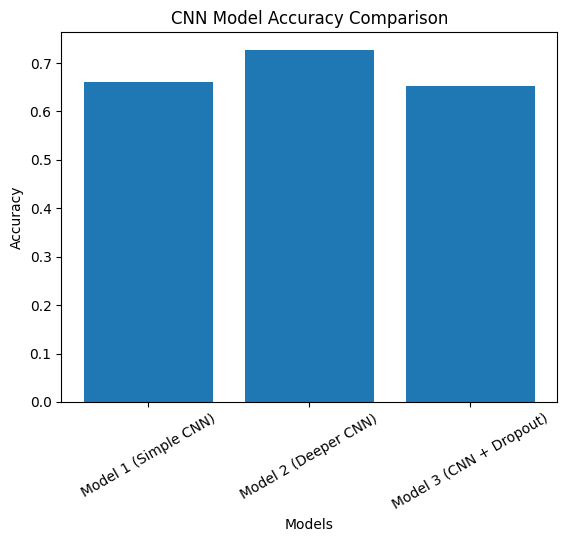

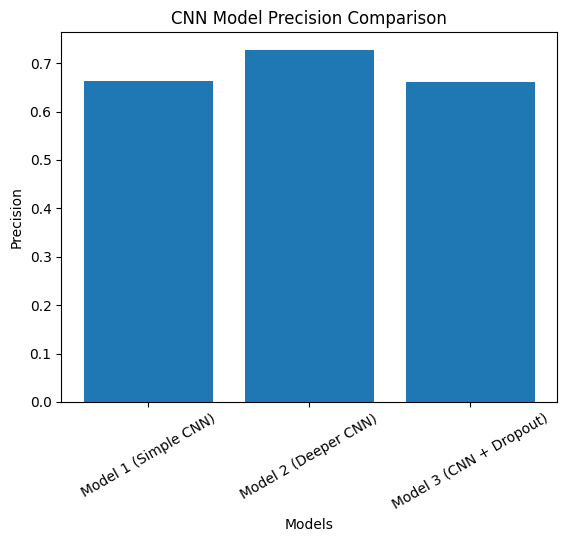

In [ ]:

# ================================
# 1. Import Libraries
# ================================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.metrics import precision_score

# ================================
# 2. Load Dataset (CIFAR-10)
# ================================
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
X_train, X_test = X_train / 255.0, X_test / 255.0

# ================================
# 3. Build CNN Models (Different Architectures)
# ================================

# 🔹 Model 1: Simple CNN
def build_model_1():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# 🔹 Model 2: Deeper CNN
def build_model_2():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# 🔹 Model 3: CNN with Dropout (Regularization)
def build_model_3():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

# ================================
# 4. Compile, Train & Evaluate
# ================================
def train_and_evaluate(model, name):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"\nTraining {name}...")

    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    # Evaluate Accuracy
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # Predictions for Precision
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    precision = precision_score(y_test, y_pred_classes, average='macro')

    print(f"\n{name} Results:")
    print("Accuracy :", test_acc)
    print("Precision:", precision)

    return test_acc, precision

# ================================
# 5. Train All Models
# ================================
results = []

models_list = [
    ("Model 1 (Simple CNN)", build_model_1()),
    ("Model 2 (Deeper CNN)", build_model_2()),
    ("Model 3 (CNN + Dropout)", build_model_3())
]

for name, model in models_list:
    acc, prec = train_and_evaluate(model, name)
    results.append([name, acc, prec])

# ================================
# 6. Comparison Table
# ================================
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision"])

print("\n===== MODEL COMPARISON =====")
print(results_df)

# ================================
# 7. Plot Accuracy
# ================================
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=30)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("CNN Model Accuracy Comparison")
plt.show()

# ================================
# 8. Plot Precision
# ================================
plt.figure()
plt.bar(results_df["Model"], results_df["Precision"])
plt.xticks(rotation=30)
plt.xlabel("Models")
plt.ylabel("Precision")
plt.title("CNN Model Precision Comparison")
plt.show()